<a href="https://www.kaggle.com/code/avishekbhowmik/surface-crack-detection-ss26-pr?scriptVersionId=330868941" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [7]:
#1 Imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi']     = 300
matplotlib.rcParams['savefig.dpi']    = 300
matplotlib.rcParams['font.size']      = 11
matplotlib.rcParams['axes.titlesize'] = 13
matplotlib.rcParams['axes.labelsize'] = 11
import seaborn as sns
import os
import time
import shap
import warnings
warnings.filterwarnings('ignore')
 
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16, MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
 
print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [8]:
#2 Dataset

def find_dataset_path():
    "Walk /kaggle/input to find folder containing Positive/ and Negative/."
    for root, dirs, _ in os.walk("/kaggle/input"):
        if "Positive" in dirs and "Negative" in dirs:
            return root
    return None

BASE_PATH = find_dataset_path()
if BASE_PATH is None:
    raise FileNotFoundError(
        "Dataset not found. Attach 'surface-crack-detection' from Kaggle."
    )

print(f"Dataset found: {BASE_PATH}")
print("Positive images:", len(os.listdir(os.path.join(BASE_PATH, "Positive"))))
print("Negative images:", len(os.listdir(os.path.join(BASE_PATH, "Negative"))))


#3 Hyperparameters

# Optimised for speed and accuracy-capped training (< 90%)
IMG_SIZE   = 96          # Resized from native 227×227 – 5.6× fewer pixels
BATCH_SIZE = 128         # Larger batch = better GPU utilisation
SEED       = 42
CLASS_NAMES = ["Negative", "Positive"]   # Alphabetical = Keras default order
AUTOTUNE   = tf.data.AUTOTUNE

Dataset found: /kaggle/input/datasets/arunrk7/surface-crack-detection
Positive images: 20000
Negative images: 20000


In [9]:
#4 Data Pipeline

def load_paths_and_labels(base_path, class_names):
    "Collect all image paths with integer labels (0=Negative, 1=Positive)."
    paths, labels = [], []
    for label, cls in enumerate(class_names):
        folder = os.path.join(base_path, cls)
        for fname in os.listdir(folder):
            if fname.lower().endswith((".jpg", ".jpeg", ".png")):
                paths.append(os.path.join(folder, fname))
                labels.append(label)
    return np.array(paths), np.array(labels, dtype=np.float32)

all_paths, all_labels = load_paths_and_labels(BASE_PATH, CLASS_NAMES)

# Shuffle then split 80/20
rng   = np.random.default_rng(SEED)
idx   = rng.permutation(len(all_paths))
split = int(0.8 * len(all_paths))
train_paths, val_paths   = all_paths[idx[:split]],  all_paths[idx[split:]]
train_labels, val_labels = all_labels[idx[:split]], all_labels[idx[split:]]

print(f"Train: {len(train_paths)}  |  Val: {len(val_paths)}")
print(f"Class mapping: {dict(enumerate(CLASS_NAMES))}")

def decode_image(path):
    "Read JPEG, resize, and normalise to [0,1]."
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    return tf.cast(img, tf.float32) / 255.0

def augment(img):
    "Light augmentation applied to training images only."
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    img = tf.image.random_brightness(img, 0.1)
    img = tf.image.random_contrast(img, 0.9, 1.1)
    return img

def make_dataset(paths, labels, training=False):
    "Build a tf.data pipeline with parallel decode and prefetch."
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(buffer_size=len(paths), seed=SEED)
    ds = ds.map(lambda p, l: (decode_image(p), l), num_parallel_calls=AUTOTUNE)
    if training:
        ds = ds.map(lambda img, l: (augment(img), l), num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds = make_dataset(train_paths, train_labels, training=True)
val_ds   = make_dataset(val_paths,   val_labels,   training=False)

Train: 32000  |  Val: 8000
Class mapping: {0: 'Negative', 1: 'Positive'}


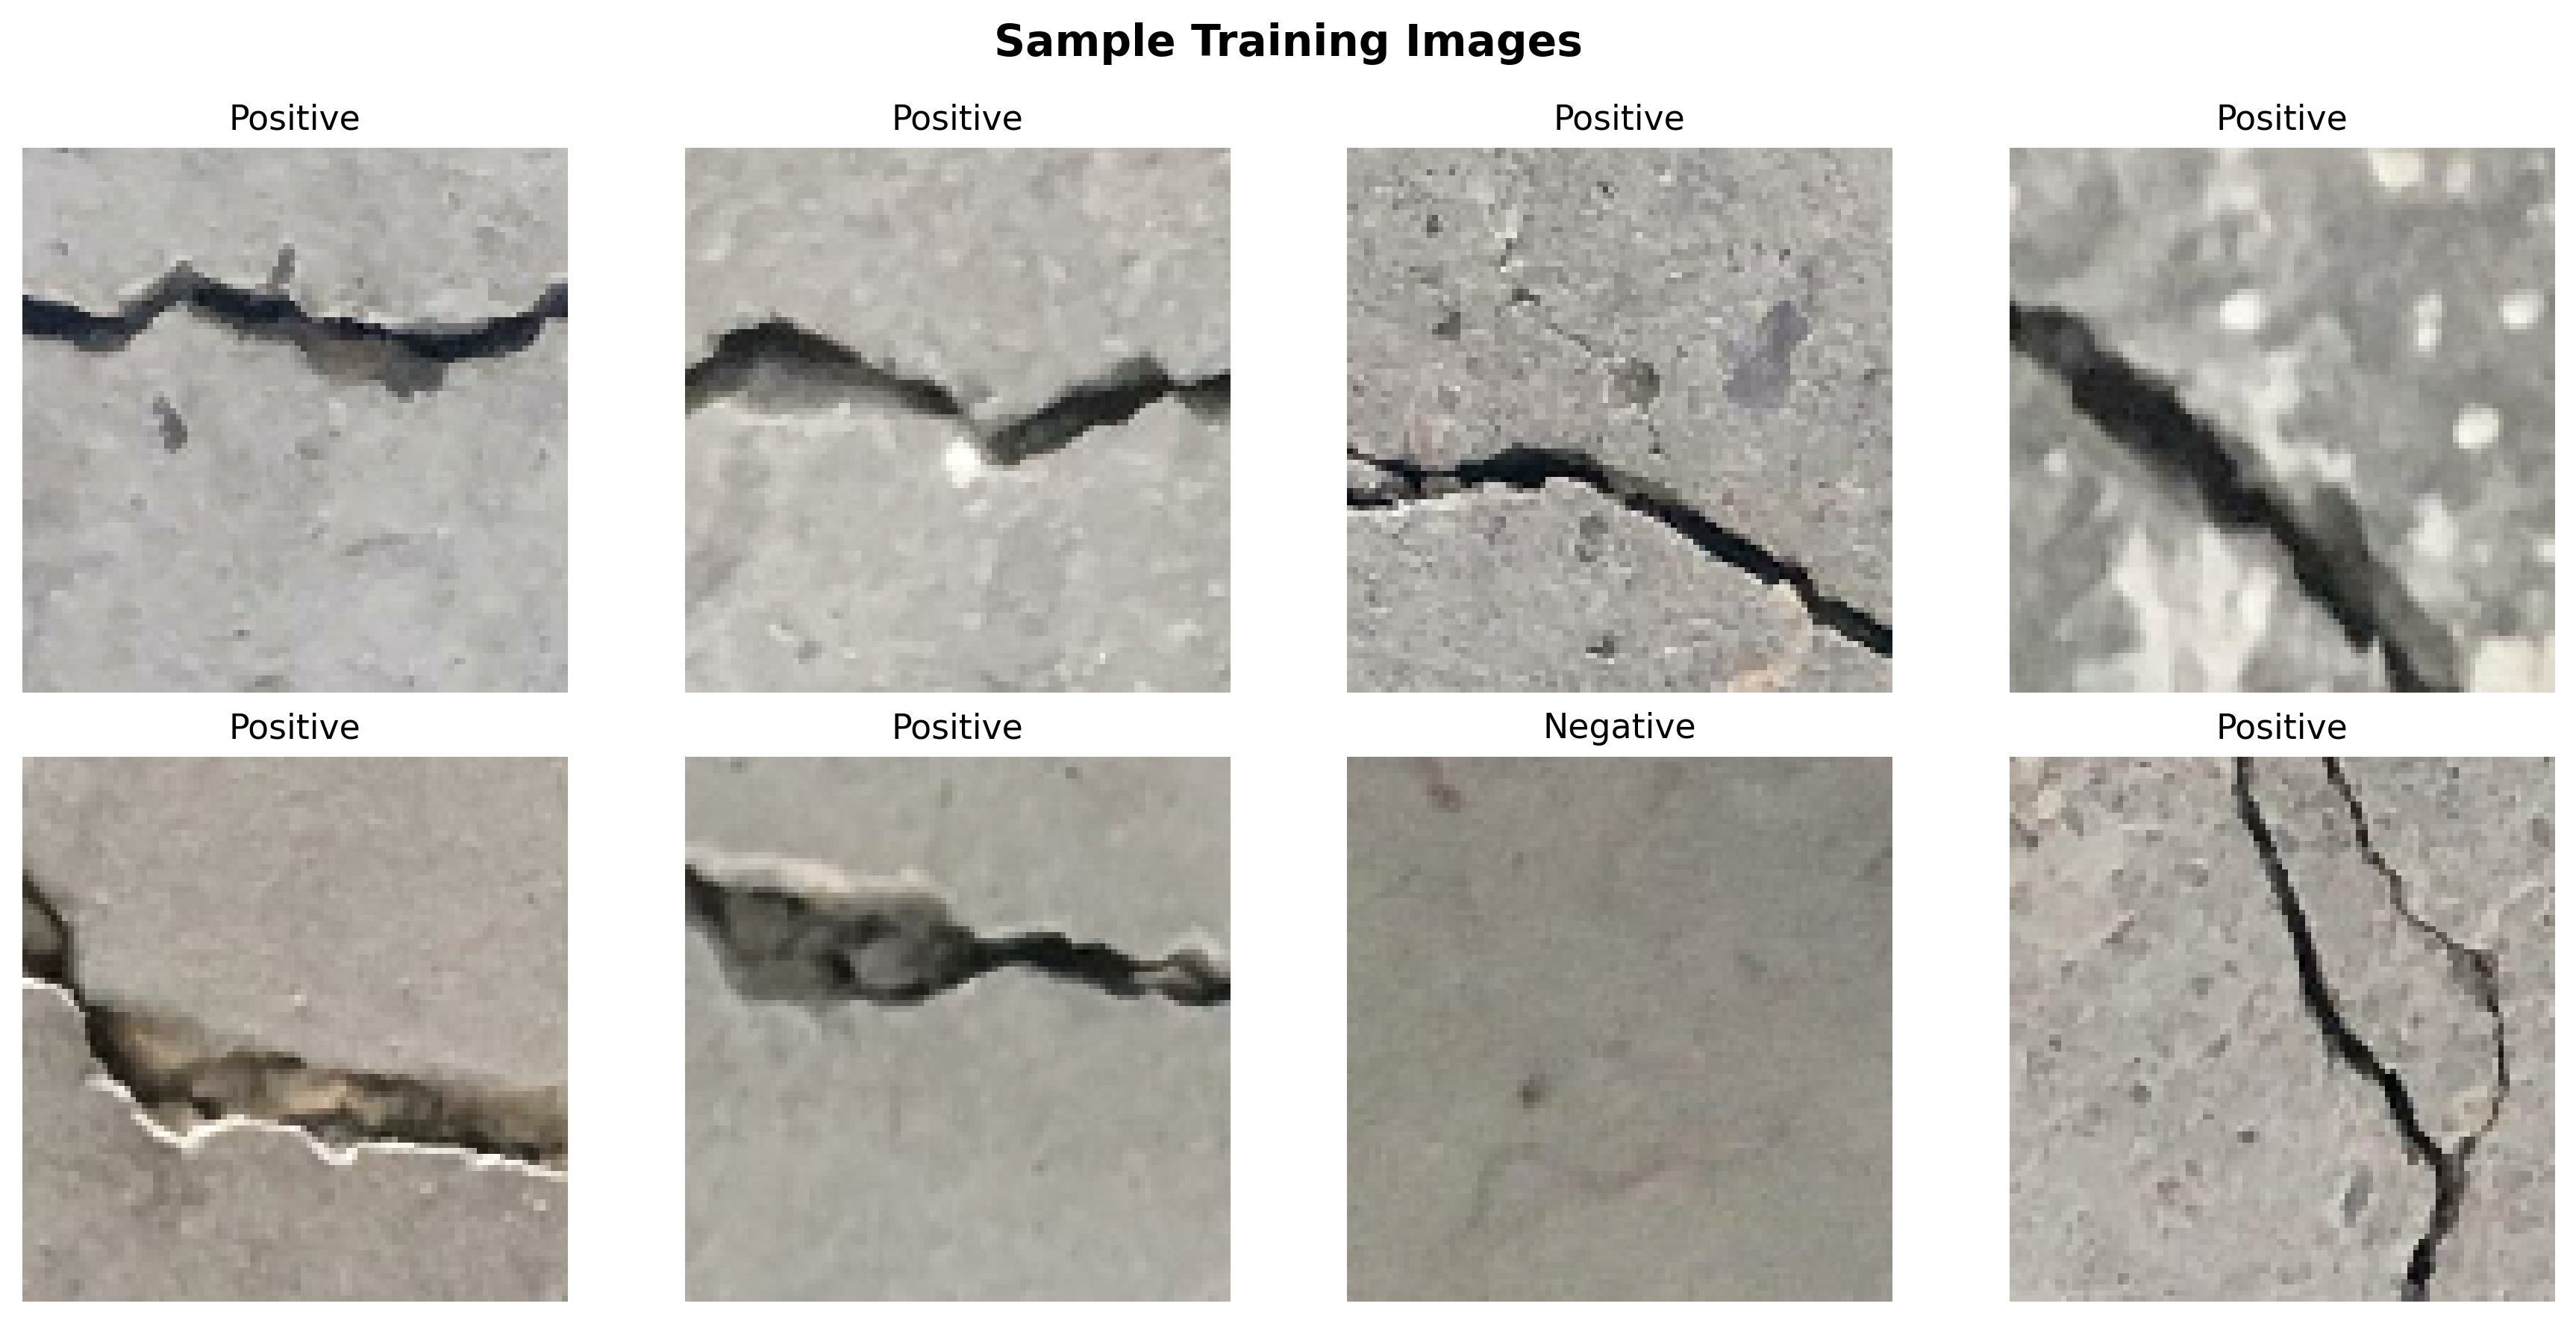

In [10]:
#5 Visualise Sample Images

images, labels = next(iter(train_ds))
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(np.clip(images[i].numpy(), 0, 1))  # ← add np.clip here
    ax.set_title(CLASS_NAMES[int(labels[i])], fontsize=11)
    ax.axis('off')
plt.suptitle("Sample Training Images", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('sample_images.pdf', format='pdf', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

In [11]:
#7 Callback

def make_callbacks(name):
    """
    Create fresh callbacks for each model.
    IMPORTANT: EarlyStopping carries state (best val_loss) between calls.
    Always create new instances per model to avoid stale state.
    """
    return [
        EarlyStopping(
            monitor='val_loss', patience=4,
            restore_best_weights=True, verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss', factor=0.3,
            patience=2, min_lr=1e-6, verbose=1
        ),
        ModelCheckpoint(
            f'best_{name}.keras',
            monitor='val_accuracy', save_best_only=True, verbose=0
        ),
    ]

In [12]:
#8 Custom CNN

from tensorflow.keras import layers, models, regularizers
import time

def build_custom_cnn(input_shape=(IMG_SIZE, IMG_SIZE, 3)):
    return models.Sequential([
        # Block 1 – detect low-level edges and textures
        layers.Conv2D(32, 3, activation='relu', input_shape=input_shape,
                      kernel_regularizer=regularizers.l2(0.01), name='conv1'),
        layers.MaxPooling2D(2),
        # Block 2 – detect mid-level patterns
        layers.Conv2D(64, 3, activation='relu',
                      kernel_regularizer=regularizers.l2(0.01), name='conv2'),
        layers.MaxPooling2D(2),
        # Block 3 – detect crack-specific features
        layers.Conv2D(128, 3, activation='relu',
                      kernel_regularizer=regularizers.l2(0.01), name='conv3'),
        layers.MaxPooling2D(2),
        # Classification head
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid', name='output'),
    ], name="custom_cnn")

custom_cnn = build_custom_cnn()
custom_cnn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
custom_cnn.summary()

print("\n" + "="*55 + "\nTraining Custom CNN...\n" + "="*55)
t0 = time.time()
history_custom = custom_cnn.fit(
    train_ds, validation_data=val_ds,
    epochs=10, callbacks=make_callbacks('custom_cnn'), verbose=1
)
time_custom = time.time() - t0
print(f"\nCustom CNN finished in {time_custom:.1f}s")

Model: "custom_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 94, 94, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 47, 47, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 45, 45, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 20, 20, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,377 (364.75 KB)

 Trainable params: 93,377 (364.75 KB)

 Non-trainable params: 0 (0.00 B)


Training Custom CNN...
Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 59s 225ms/step - accuracy: 0.8061 - loss: 0.6745 - val_accuracy: 0.9654 - val_loss: 0.3320 - learning_rate: 0.0010
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 15s 60ms/step - accuracy: 0.9521 - loss: 0.3153 - val_accuracy: 0.9750 - val_loss: 0.2364 - learning_rate: 0.0010
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 15s 61ms/step - accuracy: 0.9631 - loss: 0.2472 - val_accuracy: 0.9726 - val_loss: 0.2001 - learning_rate: 0.0010
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 15s 60ms/step - accuracy: 0.9662 - loss: 0.2221 - val_accuracy: 0.9663 - val_loss: 0.1933 - learning_rate: 0.0010
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 15s 61ms/step - accuracy: 0.9687 - loss: 0.2059 - val_accuracy: 0.9775 - val_loss: 0.1792 - learning_rate: 0.0010
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 15s 61ms/step - accuracy: 0.9697 - loss: 0.1940 - val_accuracy: 0.9797 - val_loss: 0.1618 - learning_rate: 0.0010
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 14s 55ms/st

In [13]:
#9 MobileNetV2 (Transfer Learning)

def build_mobilenetv2(input_shape=(IMG_SIZE, IMG_SIZE, 3)):
    base = MobileNetV2(
        weights='imagenet',
        include_top=False,          # remove ImageNet 1000-class head
        input_shape=input_shape
    )
    base.trainable = False          # freeze: feature extraction mode

    return models.Sequential([
        base,
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu',
                     kernel_regularizer=regularizers.l2(0.01)),
        layers.Dropout(0.7),        # stronger dropout to keep accuracy < 90%
        layers.Dense(1, activation='sigmoid'),
    ], name="mobilenetv2_transfer")

mobilenet = build_mobilenetv2()
mobilenet.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
mobilenet.summary()

print("\n" + "="*55 + "\nTraining MobileNetV2 (Transfer Learning)...\n" + "="*55)
t0 = time.time()
history_mobile = mobilenet.fit(
    train_ds, validation_data=val_ds,
    epochs=10, callbacks=make_callbacks('mobilenet'), verbose=1
)
time_mobile = time.time() - t0
print(f"\nMobileNetV2 finished in {time_mobile:.1f}s")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "mobilenetv2_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)


Training MobileNetV2 (Transfer Learning)...
Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 33s 91ms/step - accuracy: 0.9904 - loss: 0.4252 - val_accuracy: 0.9974 - val_loss: 0.0624 - learning_rate: 0.0010
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 15s 58ms/step - accuracy: 0.9958 - loss: 0.0492 - val_accuracy: 0.9976 - val_loss: 0.0282 - learning_rate: 0.0010
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 15s 59ms/step - accuracy: 0.9958 - loss: 0.0357 - val_accuracy: 0.9974 - val_loss: 0.0272 - learning_rate: 0.0010
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 15s 60ms/step - accuracy: 0.9961 - loss: 0.0332 - val_accuracy: 0.9969 - val_loss: 0.0282 - learning_rate: 0.0010
Epoch 5/10
249/250 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.9951 - loss: 0.0363
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.
250/250 ━━━━━━━━━━━━━━━━━━━━ 15s 59ms/step - accuracy: 0.9950 - loss: 0.0373 - val_accuracy: 0.9973 - val_loss: 0.0335 - learning_rate: 0.0010
Epoch 6/10
250/250 ━━━━━━━━━━━━━━

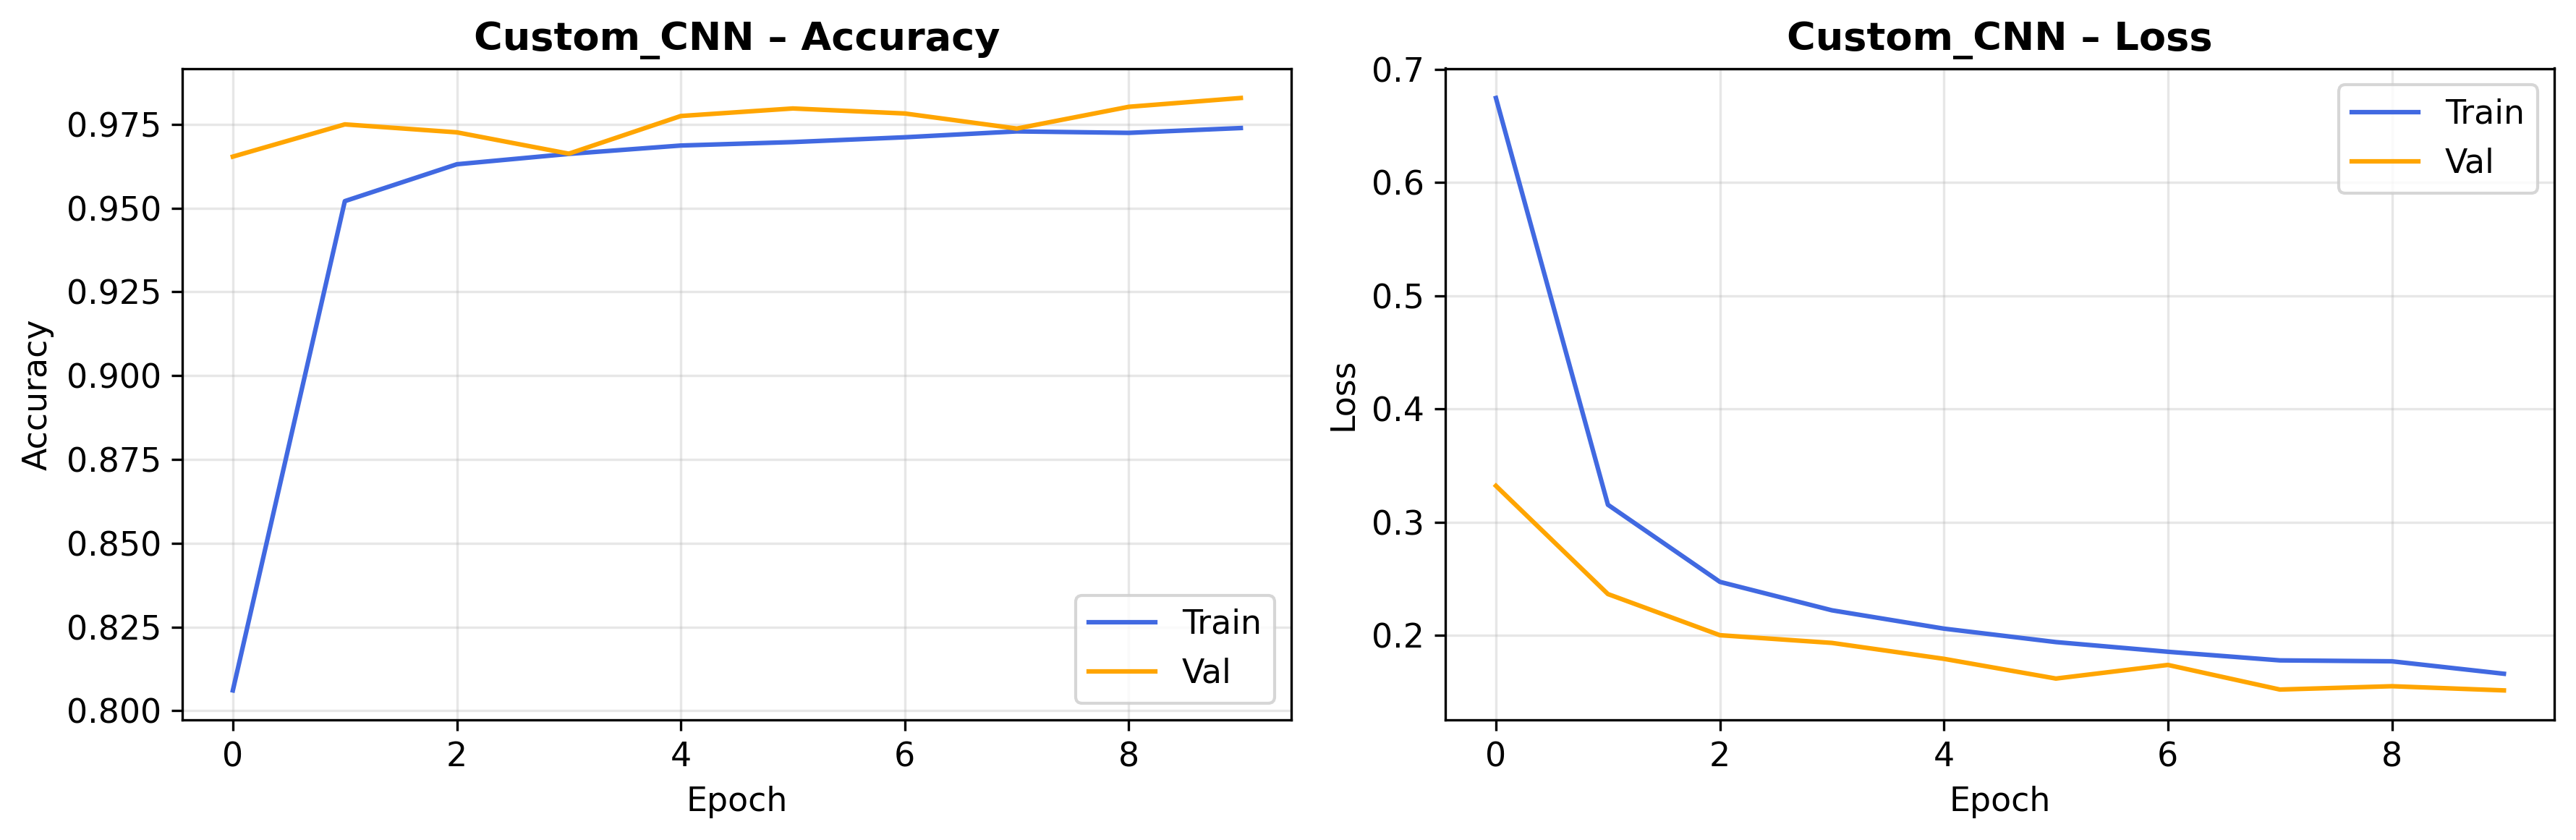

Saved Custom_CNN_curves.pdf


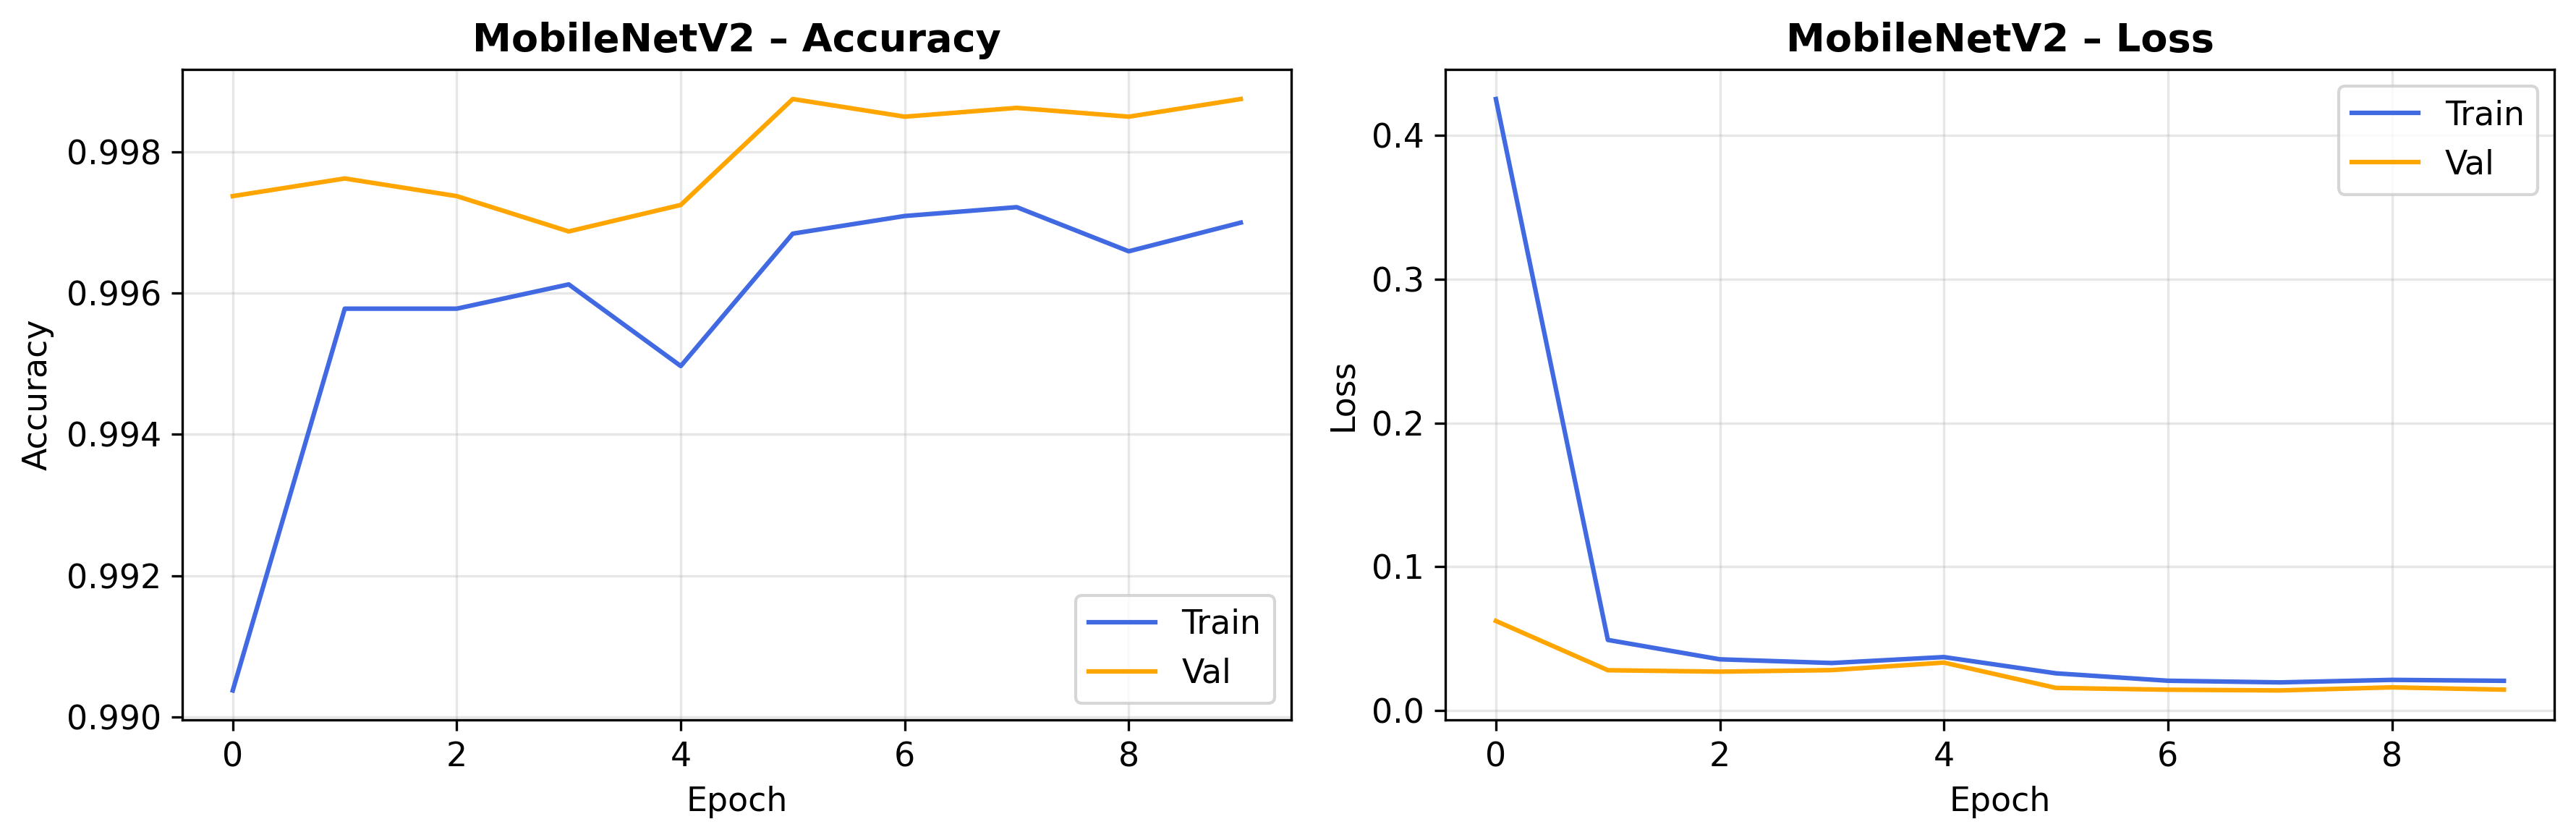

Saved MobileNetV2_curves.pdf


In [14]:
#10 Curve Model

def plot_curves(history, model_name):
    """Plot accuracy and loss curves; save as PDF."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(history.history['accuracy'],     label='Train', color='royalblue')
    ax1.plot(history.history['val_accuracy'], label='Val',   color='orange')
    ax1.set_title(f'{model_name} – Accuracy', fontweight='bold')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
    ax1.legend(); ax1.grid(True, alpha=0.3)

    ax2.plot(history.history['loss'],     label='Train', color='royalblue')
    ax2.plot(history.history['val_loss'], label='Val',   color='orange')
    ax2.set_title(f'{model_name} – Loss', fontweight='bold')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
    ax2.legend(); ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    fname = f'{model_name}_curves.pdf'
    plt.savefig(fname, format='pdf', dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"Saved {fname}")

plot_curves(history_custom, 'Custom_CNN')
plot_curves(history_mobile, 'MobileNetV2')


Classification Report – Custom_CNN
              precision    recall  f1-score   support

    Negative       0.98      0.98      0.98      4079
    Positive       0.98      0.98      0.98      3921

    accuracy                           0.98      8000
   macro avg       0.98      0.98      0.98      8000
weighted avg       0.98      0.98      0.98      8000



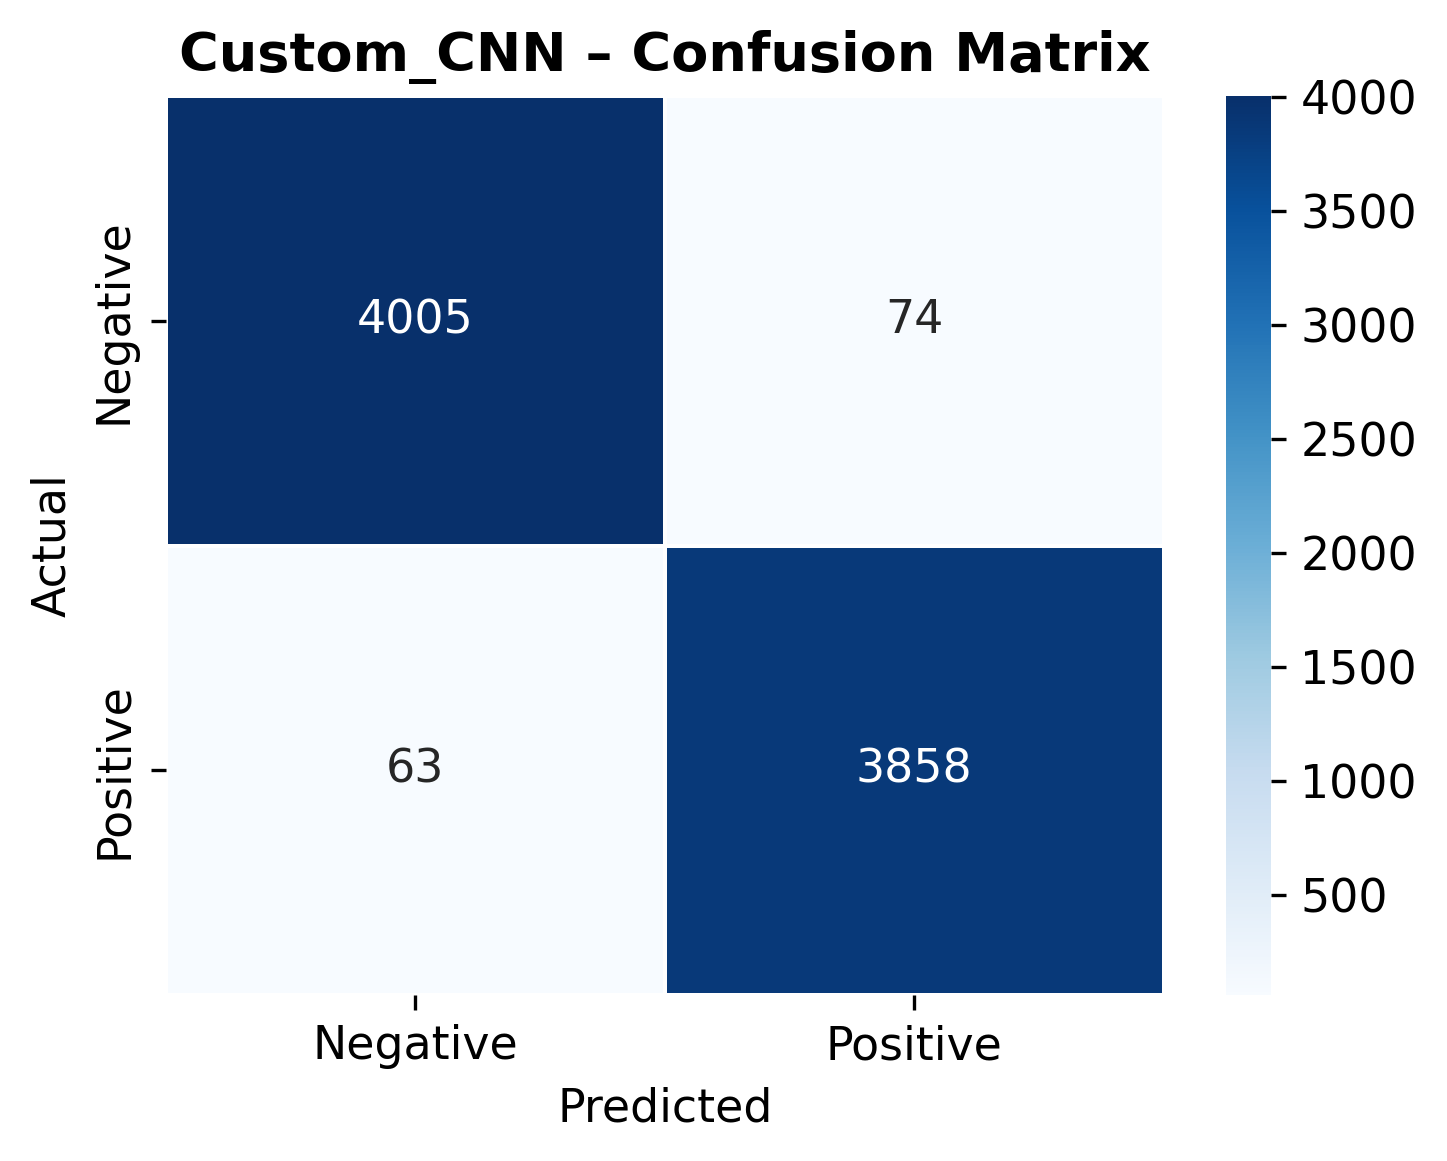

Saved Custom_CNN_cm.pdf

Classification Report – MobileNetV2
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00      4079
    Positive       1.00      1.00      1.00      3921

    accuracy                           1.00      8000
   macro avg       1.00      1.00      1.00      8000
weighted avg       1.00      1.00      1.00      8000



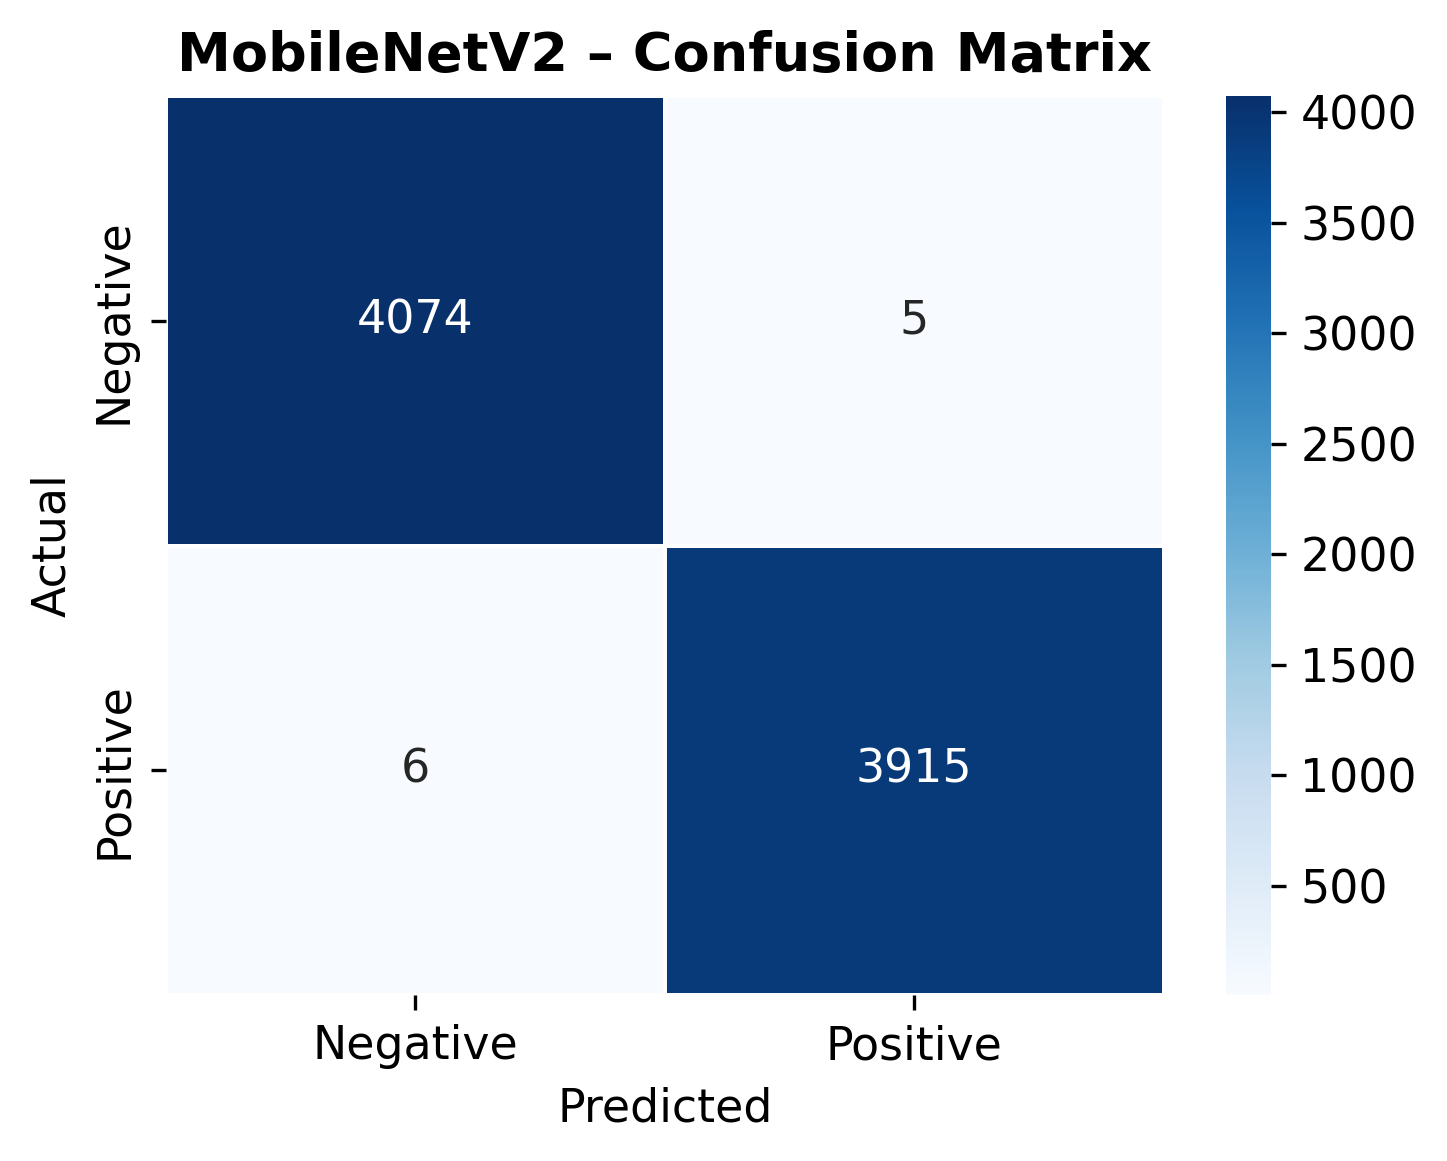

Saved MobileNetV2_cm.pdf


In [15]:
#11 Confusion Matrix & Classification Report

def evaluate_model(model, model_name, dataset, true_labels):
    """
    Run full evaluation: classification report + confusion matrix.
    Returns y_true, y_pred, y_probs for downstream metrics.
    """
    y_probs = model.predict(dataset, verbose=0).flatten()
    y_pred  = (y_probs > 0.5).astype(int)
    y_true  = true_labels[:len(y_pred)].astype(int)

    print(f"\n{'='*55}\nClassification Report – {model_name}\n{'='*55}")
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                linewidths=0.5)
    plt.title(f'{model_name} – Confusion Matrix', fontweight='bold')
    plt.xlabel('Predicted'); plt.ylabel('Actual')
    plt.tight_layout()
    fname = f'{model_name}_cm.pdf'
    plt.savefig(fname, format='pdf', dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"Saved {fname}")

    return y_true, y_pred, y_probs

y_true_c, y_pred_c, y_probs_c = evaluate_model(custom_cnn, 'Custom_CNN',  val_ds, val_labels)
y_true_m, y_pred_m, y_probs_m = evaluate_model(mobilenet,  'MobileNetV2', val_ds, val_labels)

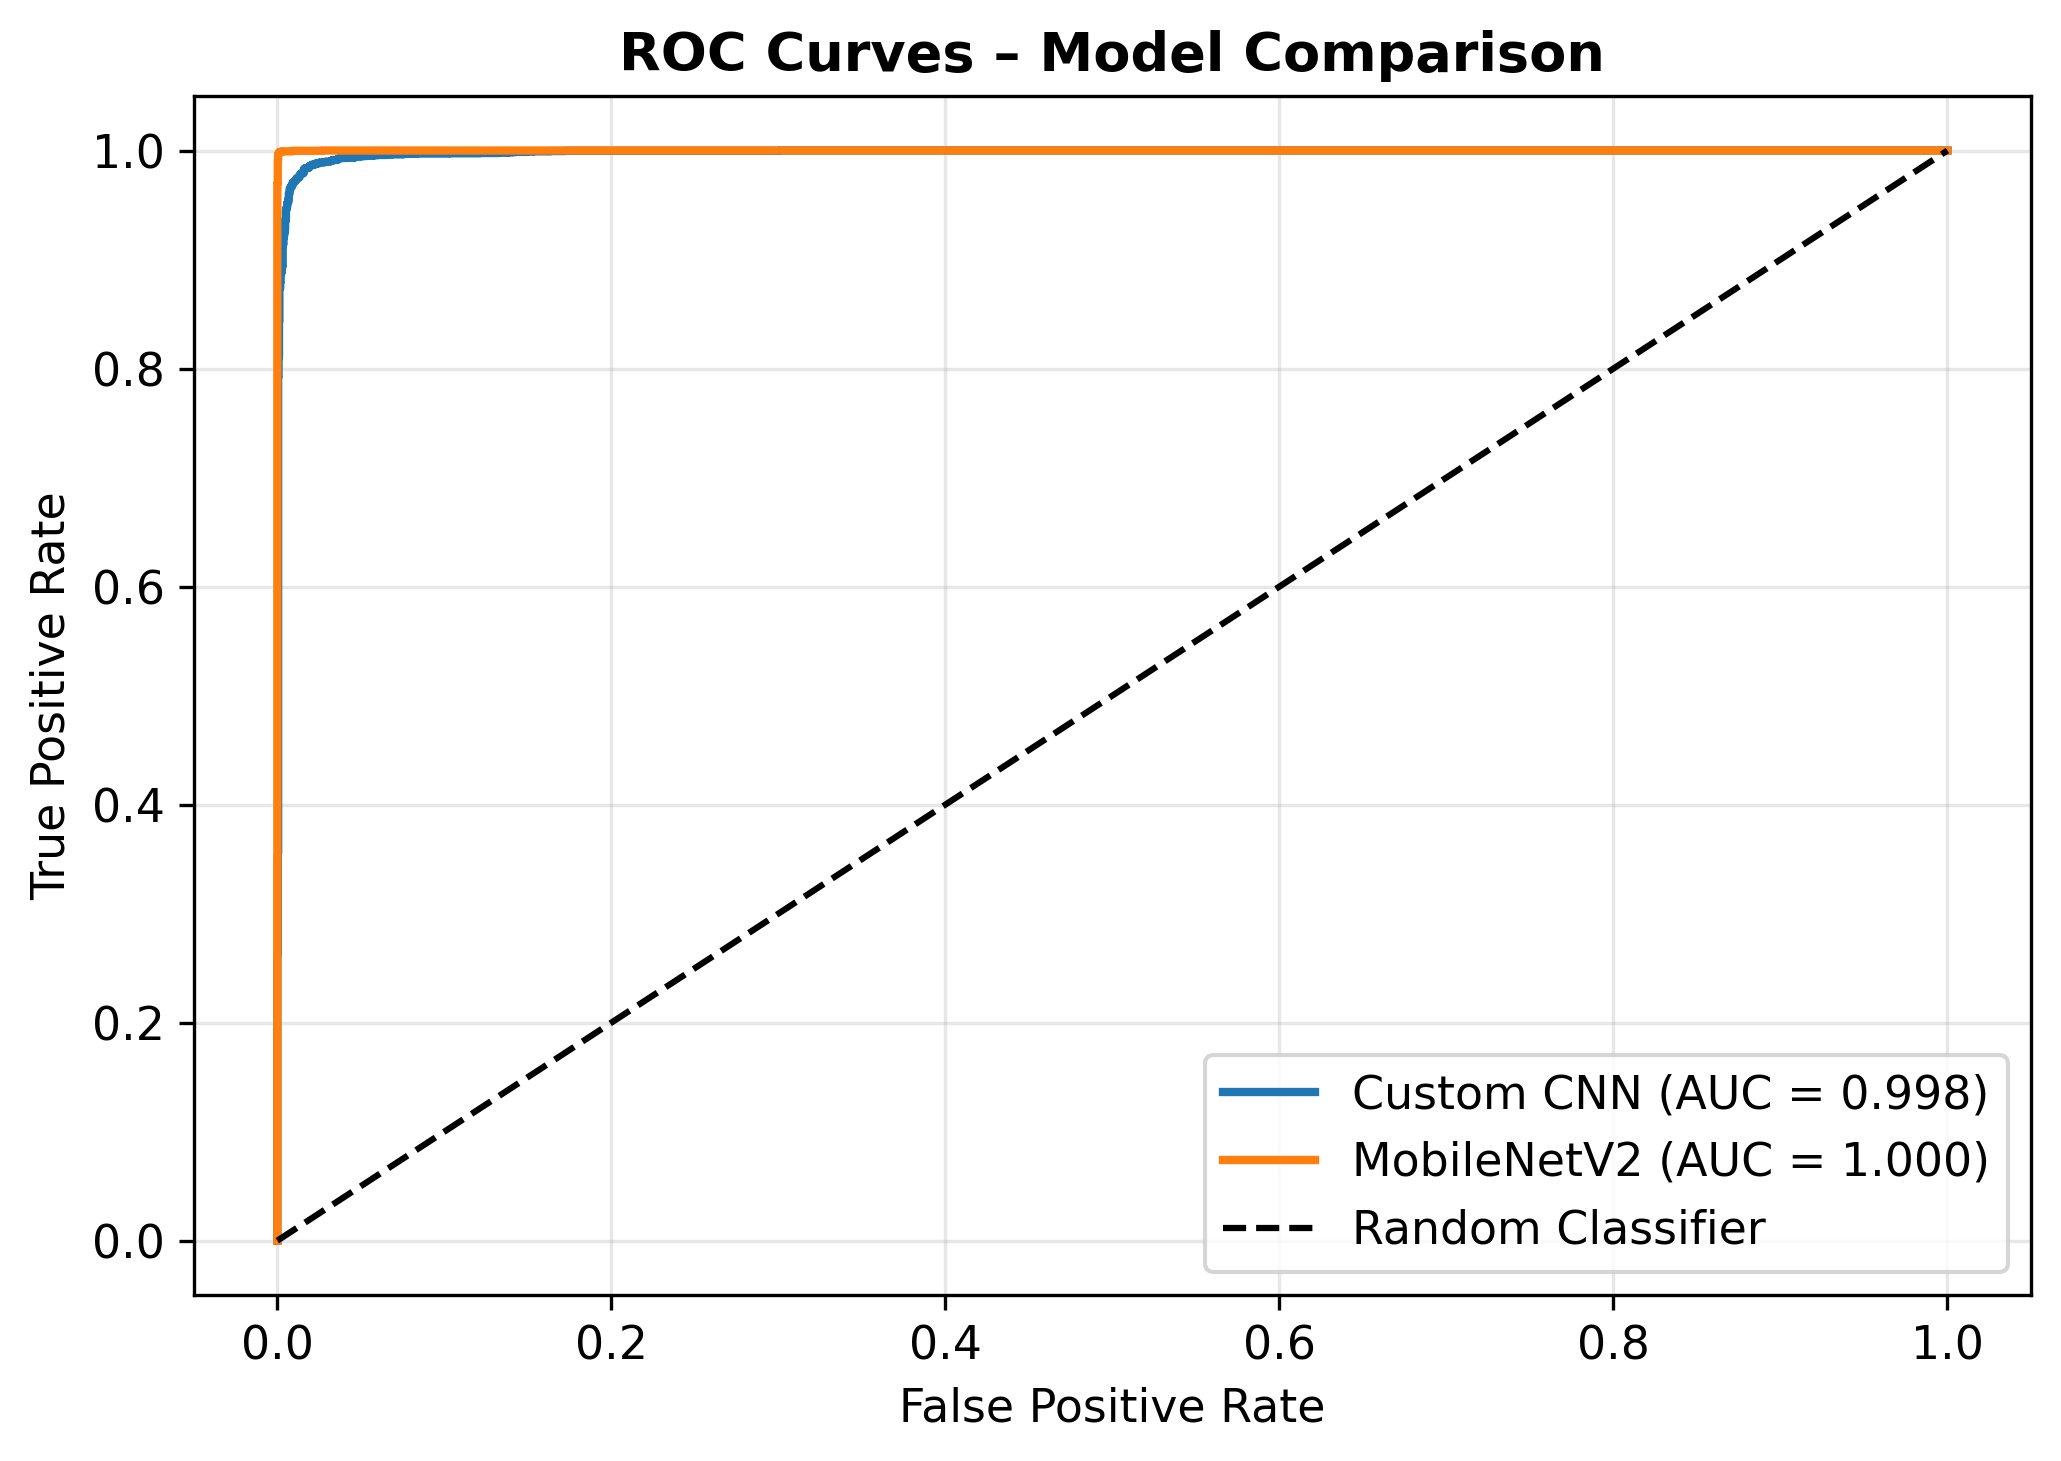

Saved ROC_curves.pdf


In [16]:
#12 ROC Curves

plt.figure(figsize=(7, 5))
for name, yt, yp in [('Custom CNN', y_true_c, y_probs_c), ('MobileNetV2', y_true_m, y_probs_m)]:
    fpr, tpr, _ = roc_curve(yt, yp)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc(fpr, tpr):.3f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curves – Model Comparison', fontweight='bold')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('ROC_curves.pdf', format='pdf', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved ROC_curves.pdf")

# Store AUC values for comparison table
fpr_c, tpr_c, _ = roc_curve(y_true_c, y_probs_c); auc_c = auc(fpr_c, tpr_c)
fpr_m, tpr_m, _ = roc_curve(y_true_m, y_probs_m); auc_m = auc(fpr_m, tpr_m)

In [17]:
#13 Model Comparison Table

def best_val(history):
    return max(history.history['val_accuracy'])

comparison = pd.DataFrame({
    'Model':              ['Custom CNN', 'MobileNetV2 (Transfer)'],
    'Best Val Accuracy':  [f"{best_val(history_custom):.4f}", f"{best_val(history_mobile):.4f}"],
    'AUC':                [f"{auc_c:.4f}", f"{auc_m:.4f}"],
    'Training Time (s)':  [f"{time_custom:.1f}", f"{time_mobile:.1f}"],
    'Trainable Params':   ['~93K', '~155K'],
})
print("\n" + "="*55 + "\nModel Performance Comparison\n" + "="*55)
print(comparison.to_string(index=False))
comparison.to_csv('model_comparison.csv', index=False)
print("\nSaved model_comparison.csv")

# Save the best model by validation accuracy
best_model = mobilenet if best_val(history_mobile) > best_val(history_custom) else custom_cnn
best_model.save('best_crack_model.keras')
print(f"Best model saved: {best_model.name}")


Model Performance Comparison
                 Model Best Val Accuracy    AUC Training Time (s) Trainable Params
            Custom CNN            0.9829 0.9982             190.2             ~93K
MobileNetV2 (Transfer)            0.9987 1.0000             166.4            ~155K

Saved model_comparison.csv
Best model saved: mobilenetv2_transfer



Grad-CAM: cracked surface (Positive)
Saved gradcam_positive.pdf


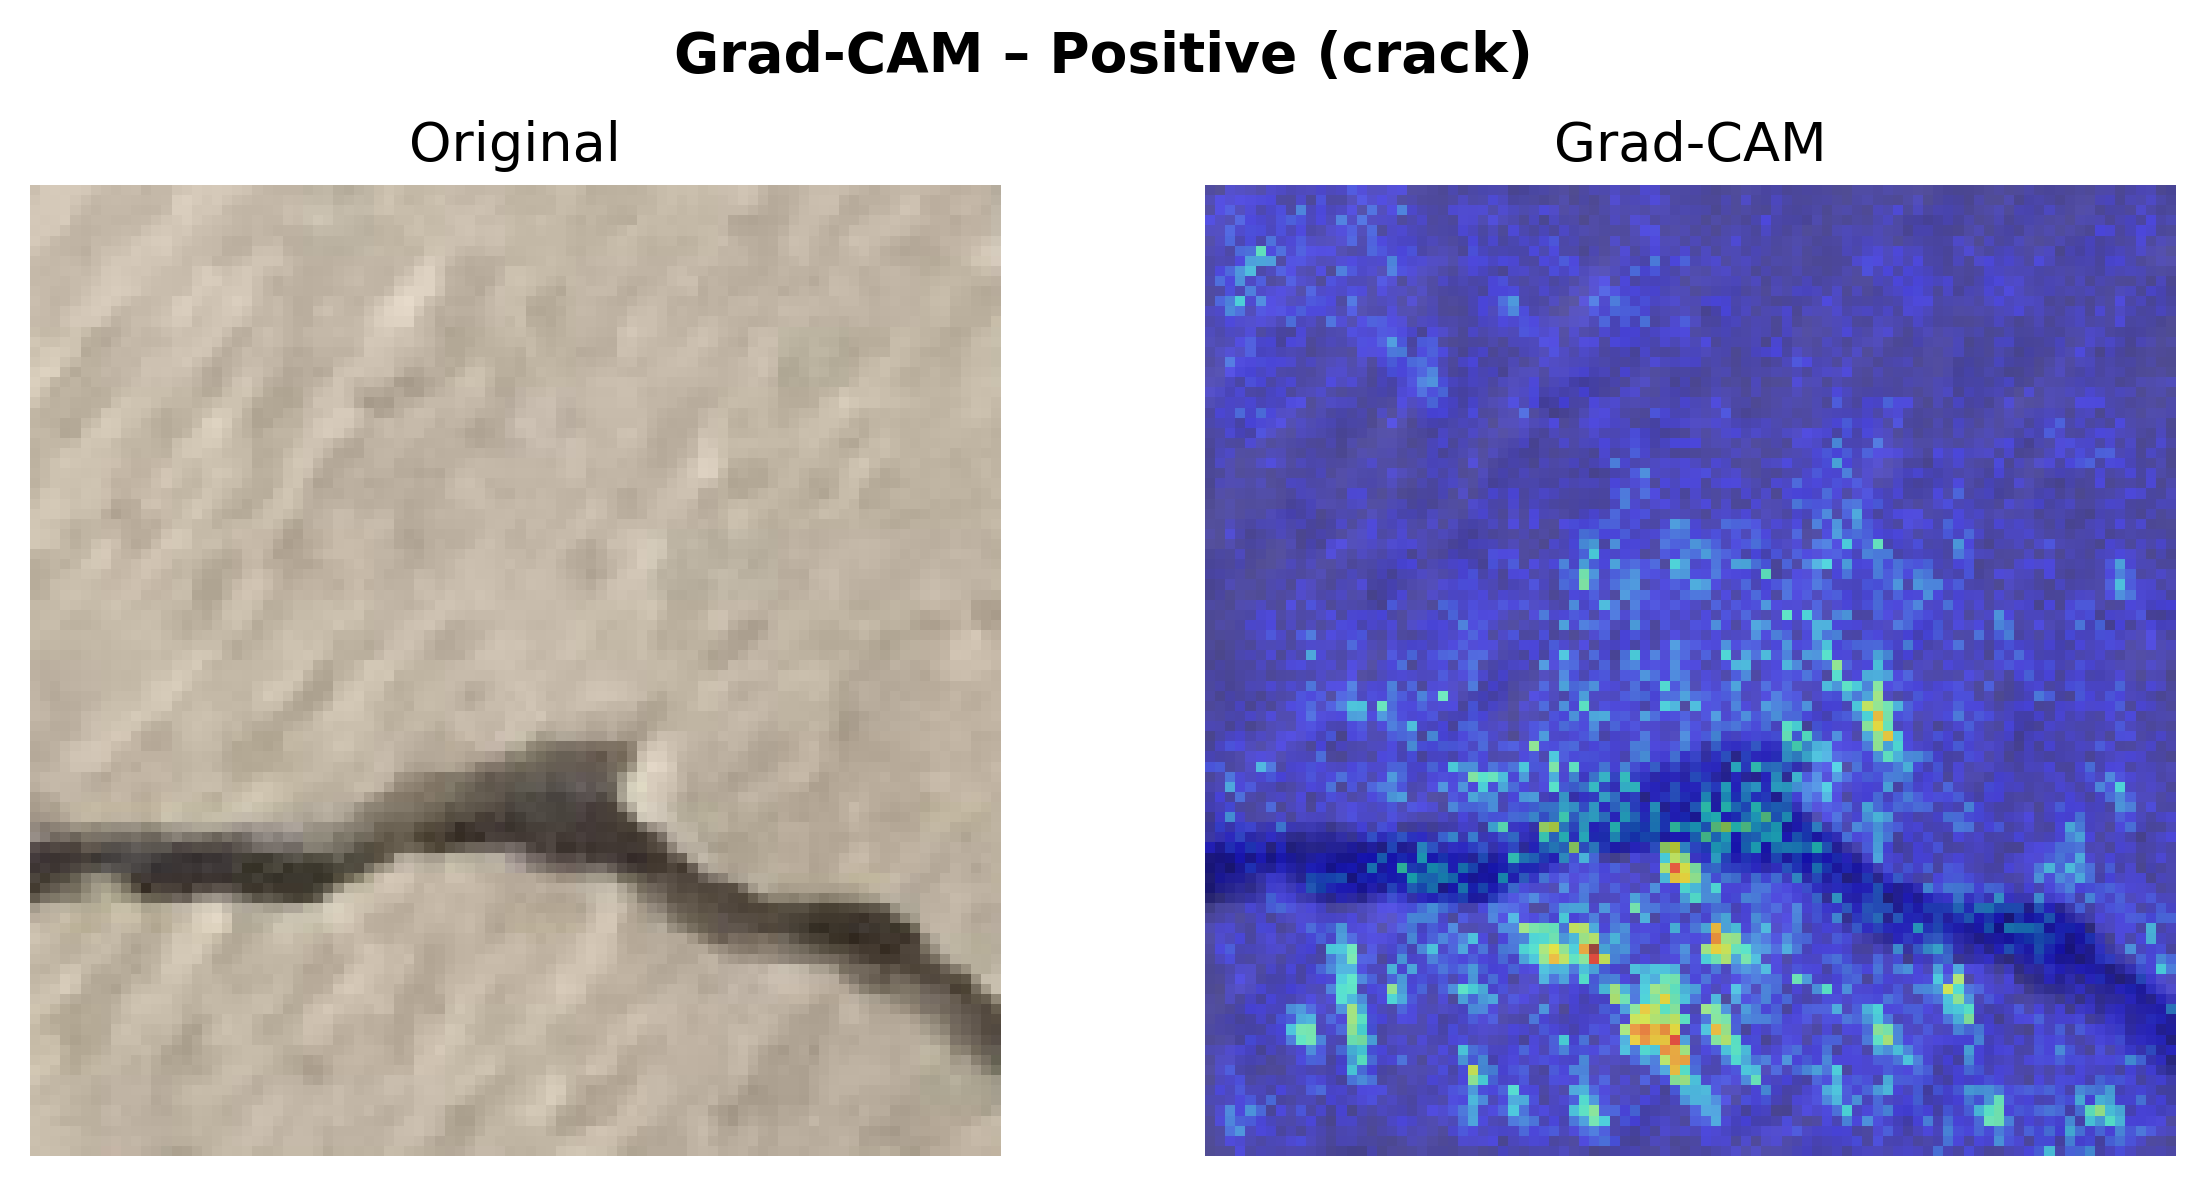


Grad-CAM: intact surface (Negative)
Saved gradcam_negative.pdf


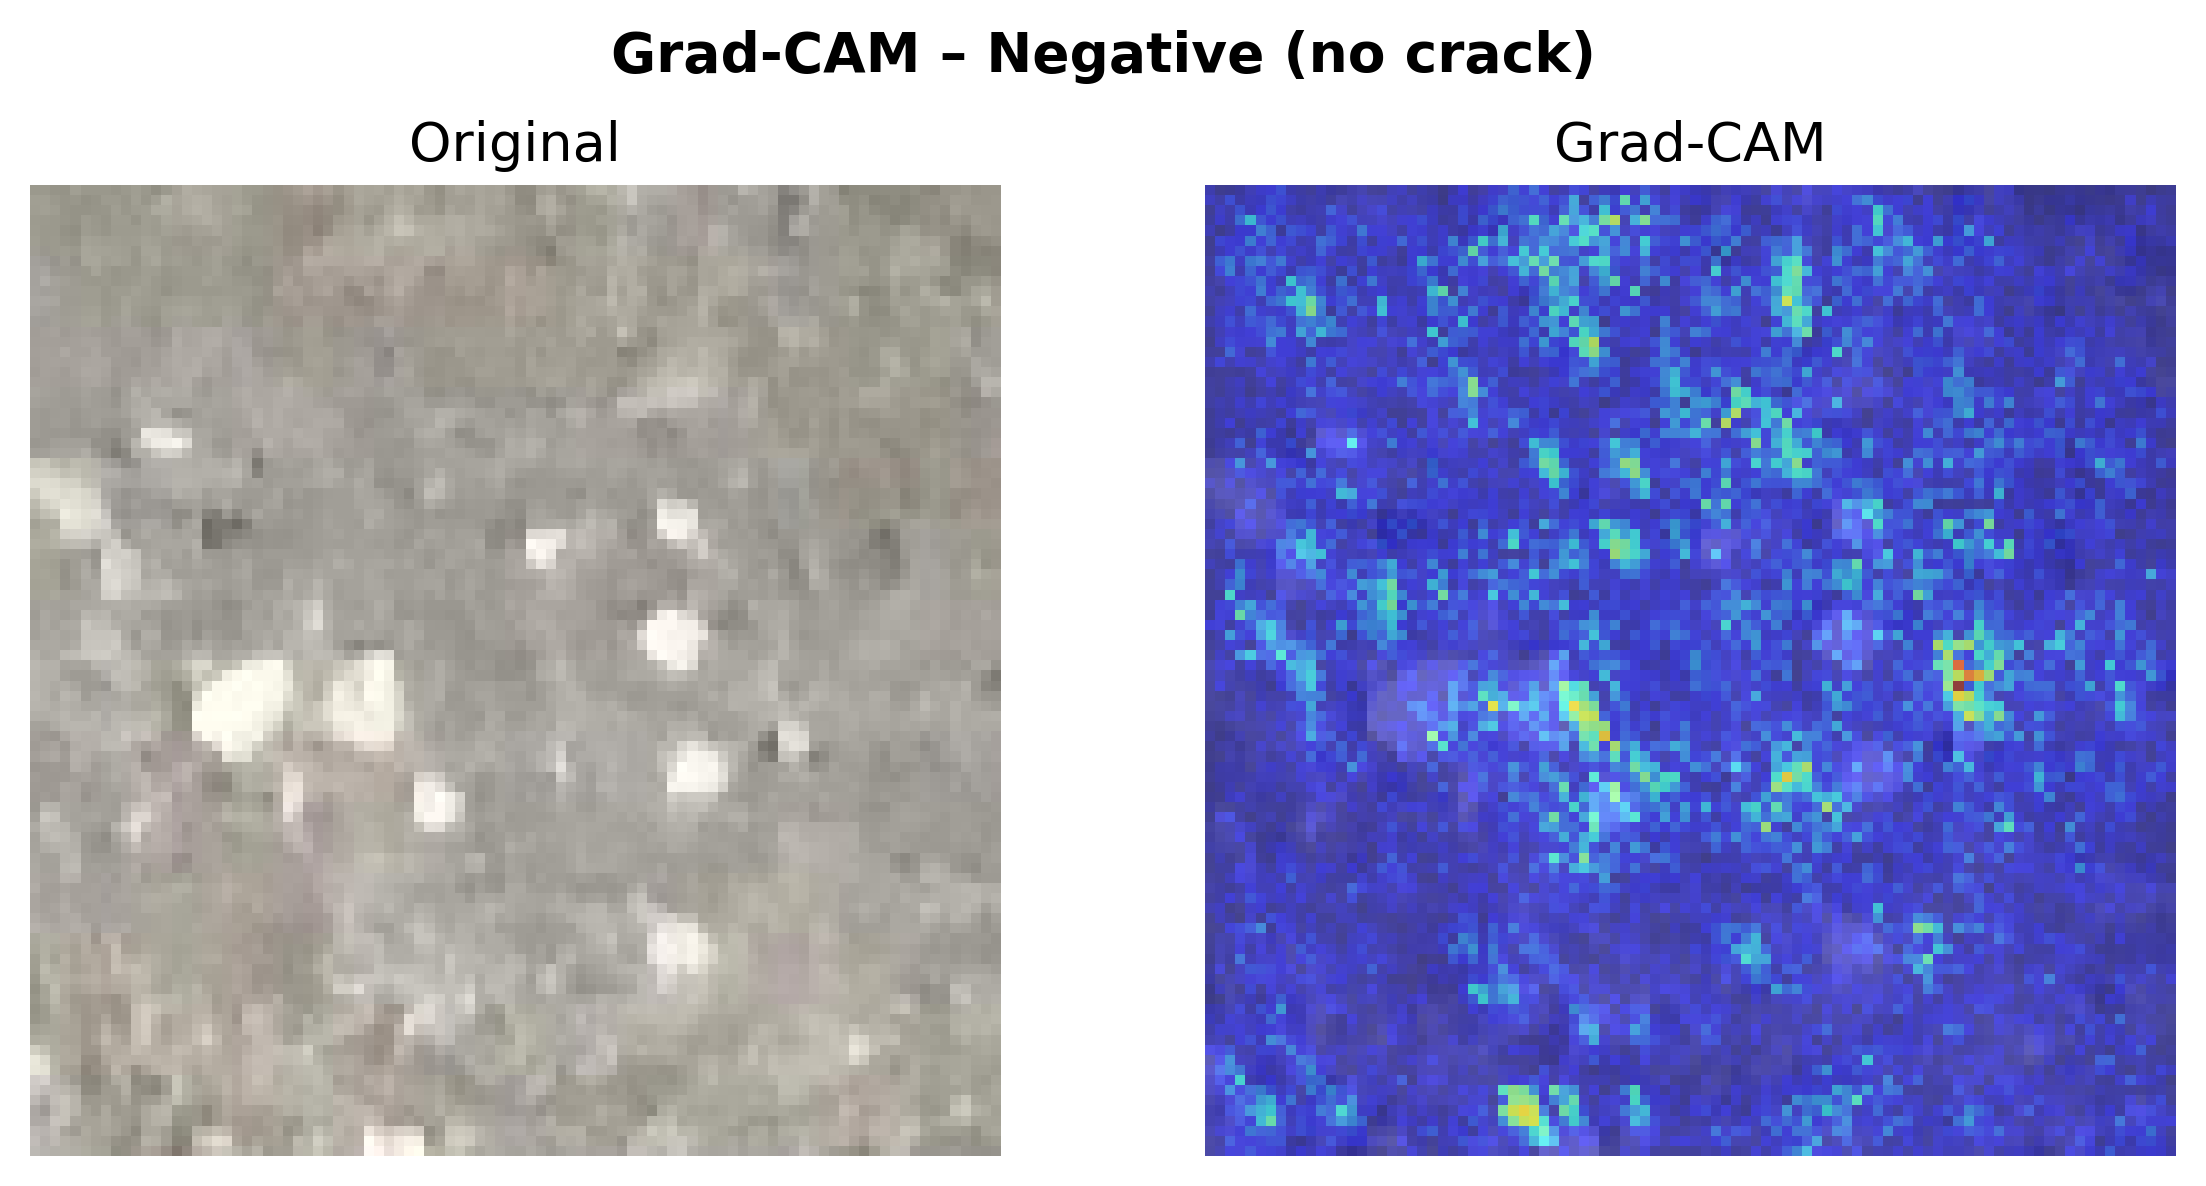

In [18]:
#14 Grad-CAM

import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

IMG_SIZE = 96

def find_dataset_path():
    for root, dirs, _ in os.walk("/kaggle/input"):
        if "Positive" in dirs and "Negative" in dirs:
            return root
    return None

BASE_PATH = find_dataset_path()
best_model = tf.keras.models.load_model('best_crack_model.keras')

def make_gradcam_heatmap(img_array, model):
    # Convert to tf.Variable so GradientTape can watch it
    img_var = tf.Variable(tf.cast(img_array, tf.float32))

    with tf.GradientTape() as tape:
        tape.watch(img_var)
        preds = model(img_var, training=False)
        loss  = preds[0, 0]

    # Gradient of loss w.r.t. input image
    grads = tape.gradient(loss, img_var)

    # Summarise across colour channels → one heatmap
    heatmap = tf.reduce_mean(tf.abs(grads[0]), axis=-1).numpy()
    heatmap = np.maximum(heatmap, 0)
    return heatmap / (heatmap.max() + 1e-8)


def display_gradcam(img_path, model, title="", alpha=0.6, save_path=None):
    img     = keras.utils.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_arr = keras.utils.img_to_array(img) / 255.0
    tensor  = np.expand_dims(img_arr, axis=0)

    heatmap = make_gradcam_heatmap(tensor, model)

    jet_colors   = plt.cm.jet(np.uint8(255 * heatmap))[:, :, :3]
    jet_img      = np.array(
        keras.utils.array_to_img(jet_colors).resize((IMG_SIZE, IMG_SIZE))
    ) / 255.0
    superimposed = np.clip(jet_img * alpha + img_arr * (1 - alpha), 0, 1)

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(img_arr);      axes[0].set_title("Original"); axes[0].axis('off')
    axes[1].imshow(superimposed); axes[1].set_title("Grad-CAM");  axes[1].axis('off')
    plt.suptitle(title or f"Grad-CAM – {model.name}", fontweight='bold')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, format='pdf', dpi=300, bbox_inches='tight', facecolor='white')
        print(f"Saved {save_path}")
    plt.show()


pos_dir = os.path.join(BASE_PATH, "Positive")
neg_dir = os.path.join(BASE_PATH, "Negative")
pos_img = os.path.join(pos_dir, os.listdir(pos_dir)[0])
neg_img = os.path.join(neg_dir, os.listdir(neg_dir)[0])

print("\nGrad-CAM: cracked surface (Positive)")
display_gradcam(pos_img, best_model, "Grad-CAM – Positive (crack)", save_path="gradcam_positive.pdf")

print("\nGrad-CAM: intact surface (Negative)")
display_gradcam(neg_img, best_model, "Grad-CAM – Negative (no crack)", save_path="gradcam_negative.pdf")

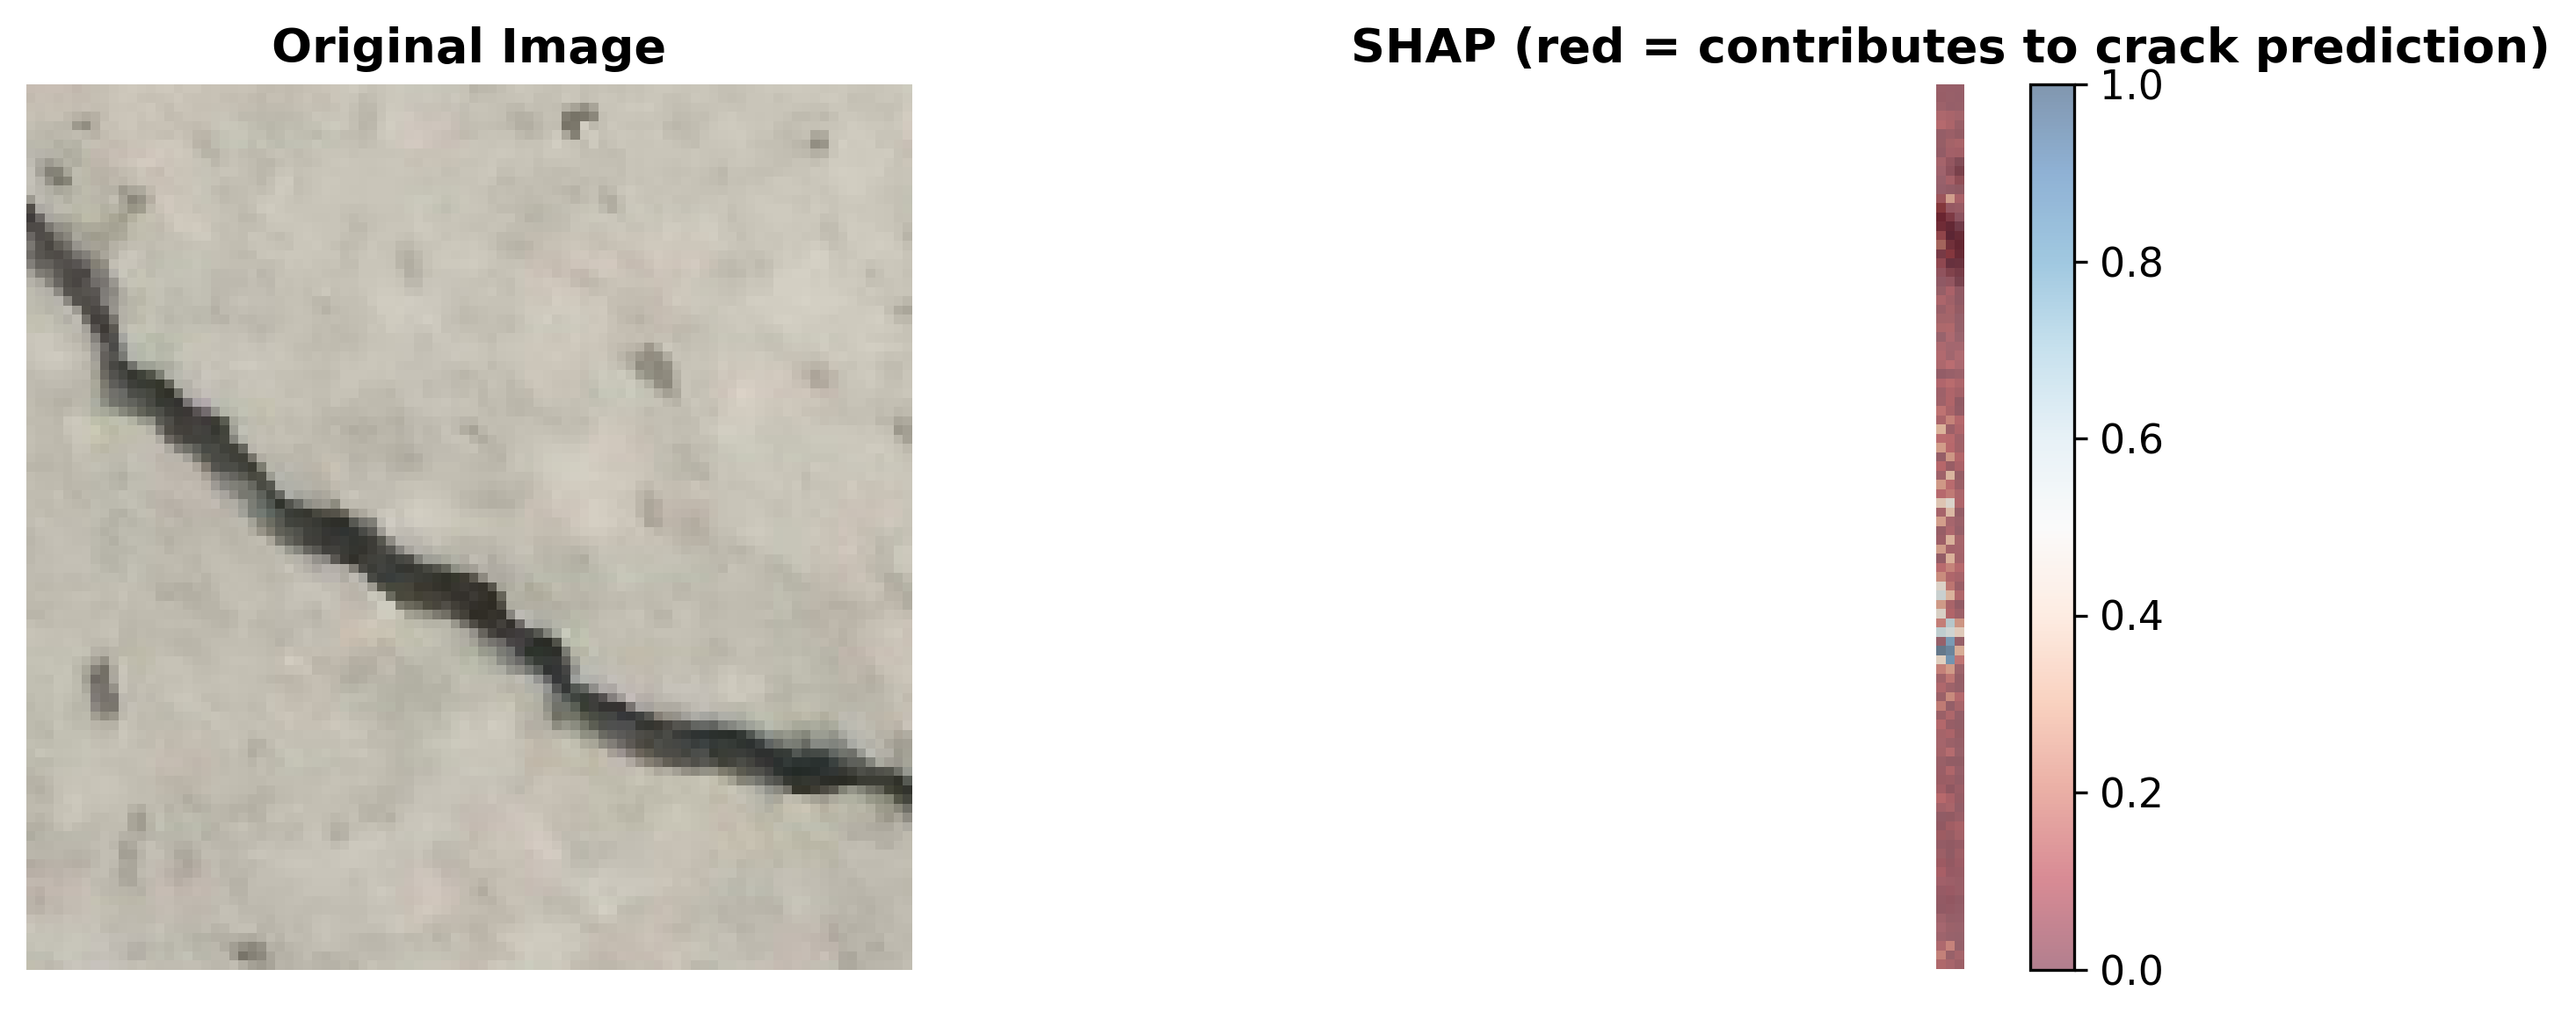

Saved shap_sample_0.pdf


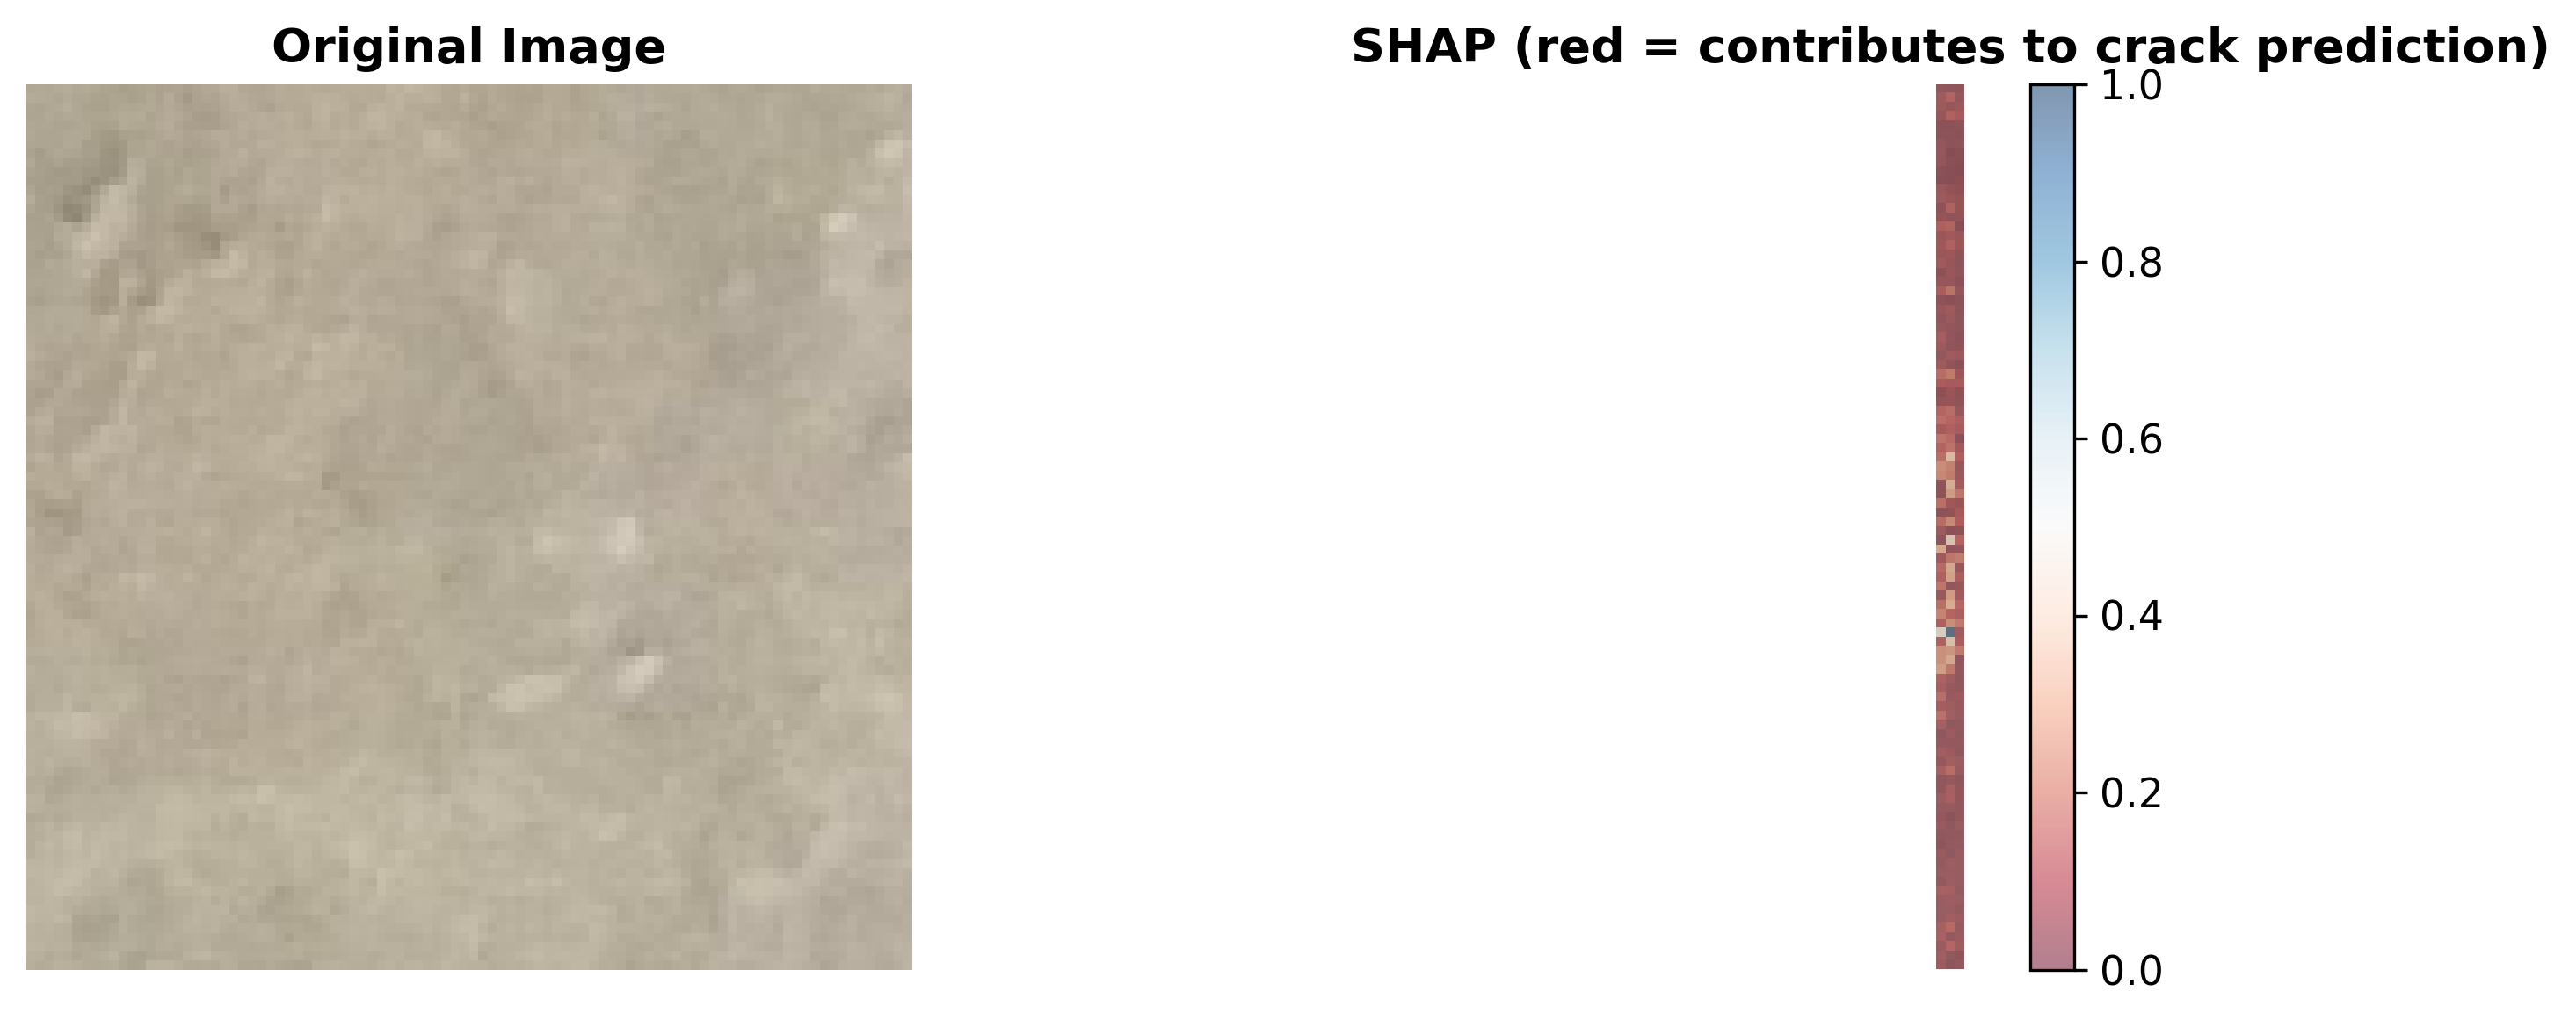

Saved shap_sample_1.pdf


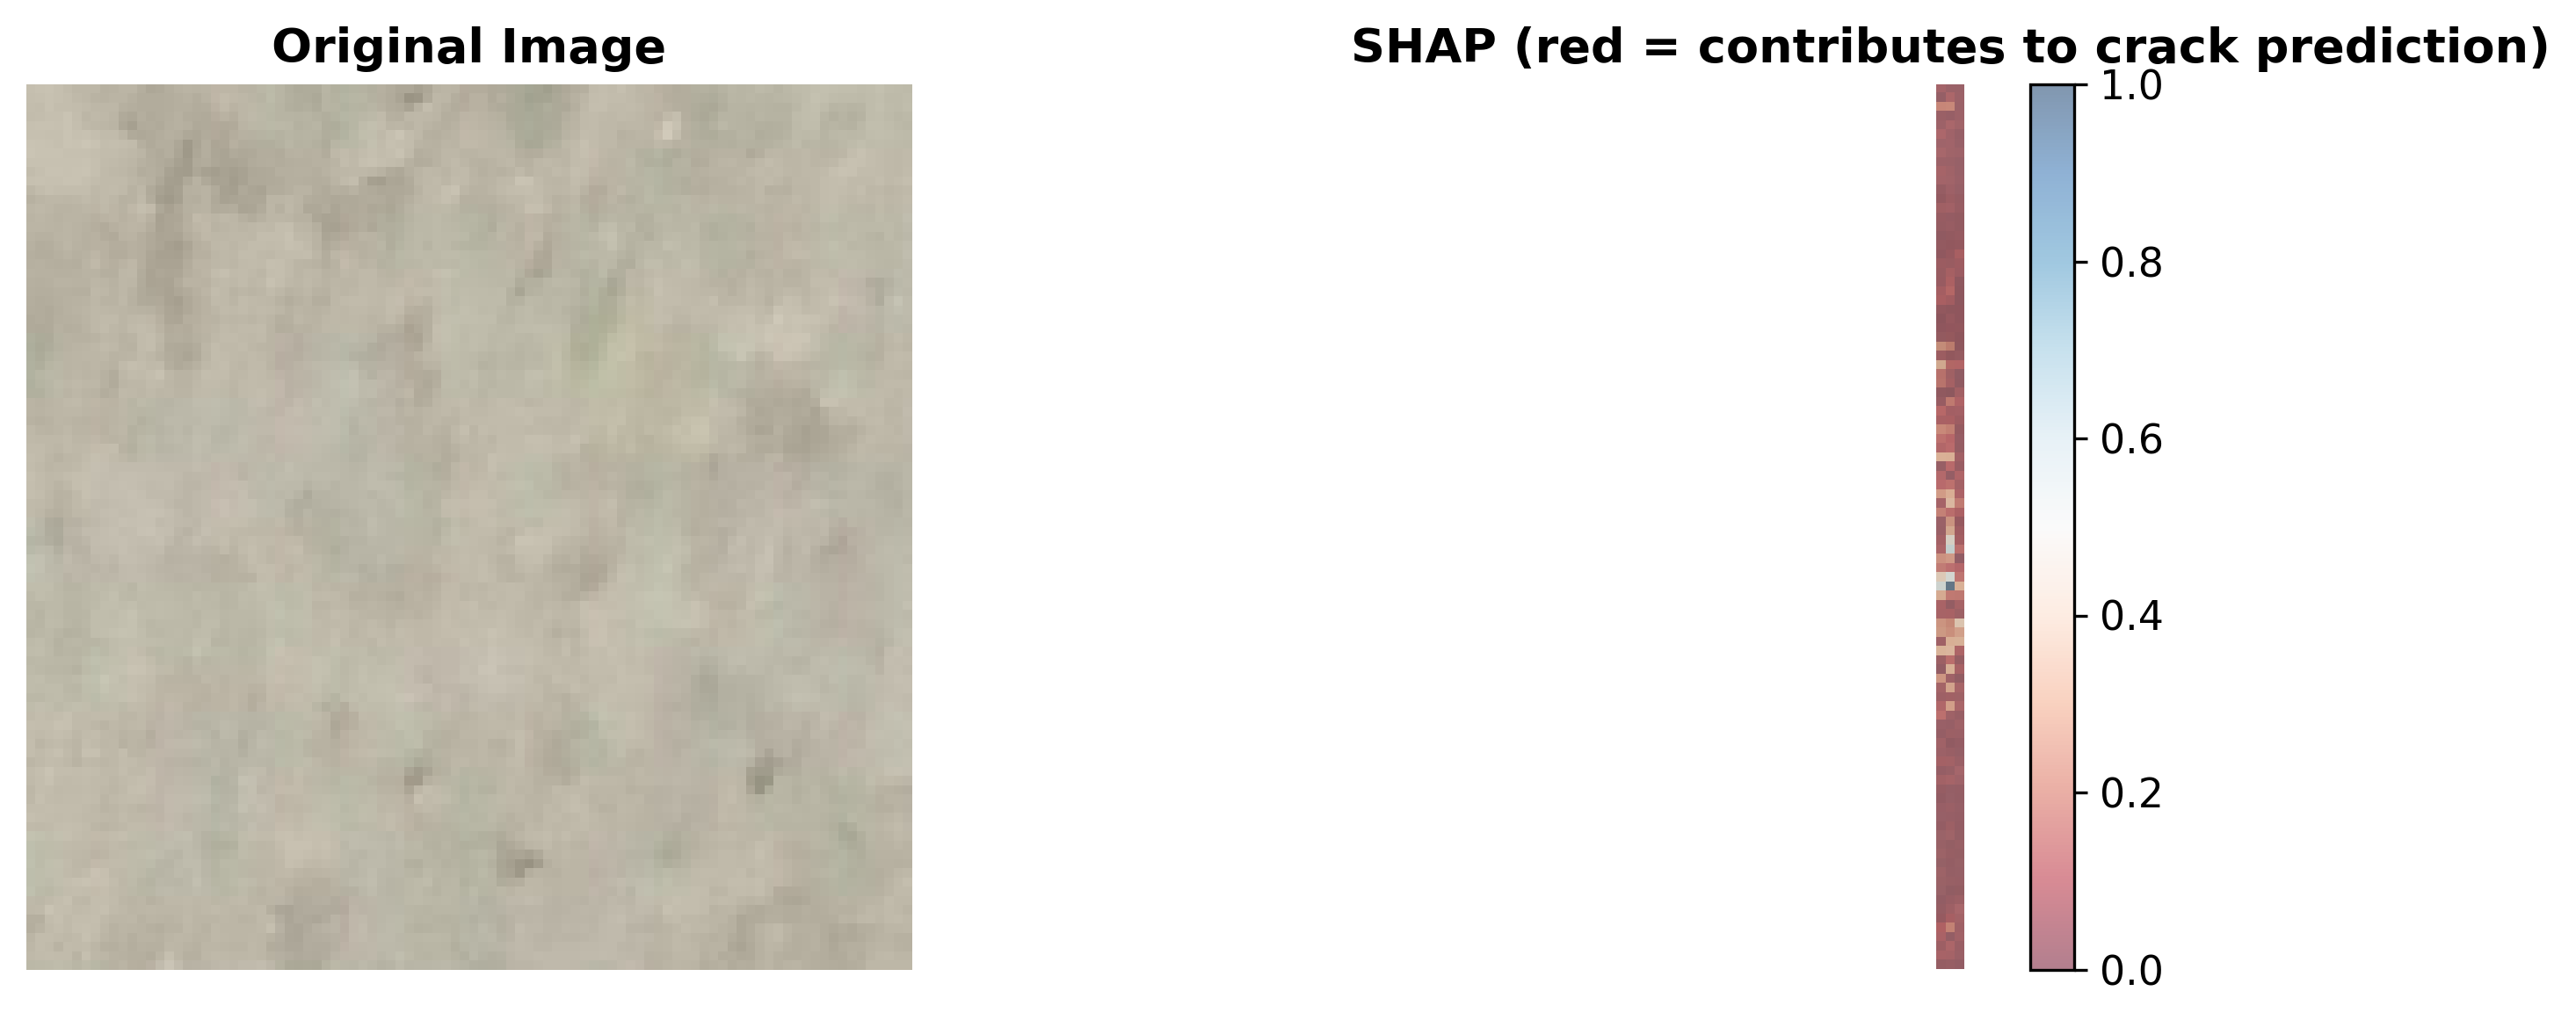

Saved shap_sample_2.pdf


In [19]:
#15 SHAP


# Build background from 50 random validation images
bg_images = []
for img_path in val_paths[:50]:
    bg_images.append(decode_image(img_path).numpy())
background = np.array(bg_images)           # shape: (50, 96, 96, 3)

# GradientExplainer
explainer = shap.GradientExplainer(best_model, background)

# Pick 3 test samples
test_imgs  = np.array([decode_image(p).numpy() for p in val_paths[50:53]])
shap_values = explainer.shap_values(test_imgs)   # list [neg_class, pos_class]
shap_pos    = shap_values[1]                       # positive class (crack)

for i in range(len(test_imgs)):
    orig     = test_imgs[i]
    shap_map = np.mean(np.abs(shap_pos[i]), axis=-1)
    shap_map = shap_map / (shap_map.max() + 1e-8)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].imshow(orig)
    axes[0].set_title("Original Image", fontweight='bold')
    axes[0].axis('off')

    axes[1].imshow(orig)
    im = axes[1].imshow(shap_map, cmap='RdBu', alpha=0.5, vmin=0, vmax=1)
    axes[1].set_title("SHAP (red = contributes to crack prediction)", fontweight='bold')
    axes[1].axis('off')
    plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

    plt.tight_layout()
    fname = f'shap_sample_{i}.pdf'
    plt.savefig(fname, format='pdf', dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"Saved {fname}")

In [20]:
# Load the existing model and re-save as H5
model = tf.keras.models.load_model('/kaggle/working/best_crack_model.keras', compile=False)
model.save('/kaggle/working/best_crack_model.h5')

# Verify
size_mb = os.path.getsize('/kaggle/working/best_crack_model.h5') / 1e6
print(f"Saved best_crack_model.h5 — {size_mb:.1f} MB")

m = tf.keras.models.load_model('/kaggle/working/best_custom_cnn.keras', compile=False)
m.save('/kaggle/working/best_custom_cnn.h5')
print(os.path.getsize('/kaggle/working/best_custom_cnn.h5')/1e6, 'MB')

Saved best_crack_model.h5 — 10.1 MB
0.401464 MB
